# 9. Обучение GNN/GAT и проверка Graph-EVT pipeline

Ноутбук использует актуальные `EpisodeLabeler`, `ProcessModelTrainer` и `EvaluationOrchestrator`. Обучающие записи строятся `evt_demo.data_generator.generate_kuramoto_propagation_recording` — той же генеративной моделью (связанные осцилляторы Курамото + Hurst/DFA-окрашенные впрыски по кольцу), что и реальный `kuramoto_propagation_series.csv`, а не упрощённым синтетическим `make_recording` библиотеки. Затем модель проверяется тремя разными способами: на отложенных эпизодах из *чужого* домена (библиотечная синтетика), на реальном CSV с *чужим* (обучающим) baseline и на реальном CSV с *его собственным* oracle-assisted baseline; ground truth реального ряда (`event_onset`, `source_channel`) берётся из `synthetic_datasets_metadata.json`.

Модель получает пять сводных признаков узла и baseline-граф. Progress bars показывают ход разметки, обучения и evaluation. Attention является весом предсказания, а не доказательством причинности.

In [9]:
from pathlib import Path
import json
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from graph_evt_agent import (
    EVTConfig,
    EpisodeLabeler,
    EvaluationCase,
    EvaluationOrchestrator,
    GraphConfig,
    GraphEVTPipeline,
    GraphLearningConfig,
    LabelingConfig,
    ProcessModelTrainer,
)
from graph_evt_agent import visualization as viz
from graph_evt_agent.input import TimeSeriesInput
from graph_evt_agent.synthetic import make_propagation_episode
from graph_evt_agent.graph import build_graph

SEED = 42
N_CHANNELS = 12
BASELINE_SIZE = 300
ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "data/generated/kuramoto_propagation_series.csv").exists())
DATA_PATH = ROOT / "data/generated/kuramoto_propagation_series.csv"

# evt_demo.data_generator is this project's own module (src-layout), not part
# of graph-evt-agent; make it importable the same way 1-d/07 and n-d/07 do.
src_path = str(ROOT / "src")
if src_path not in sys.path:
    sys.path.append(src_path)
from evt_demo.data_generator import generate_kuramoto_propagation_recording

dataframe = pd.read_csv(DATA_PATH)
channel_names = [column for column in dataframe.columns if column.startswith("channel_")]
observed_values = dataframe[channel_names].to_numpy(dtype=float)
event_mask = dataframe["is_extreme"].to_numpy(dtype=bool)
propagation_metadata = json.loads((ROOT / "data/generated/synthetic_datasets_metadata.json").read_text())["kuramoto_propagation"]
real_event_onset = int(np.flatnonzero(event_mask)[0])
real_source_channel = int(propagation_metadata["source_channel"])

# load_csv/load_timeseries would treat `is_extreme` as a 13th channel (see
# 1-d/08_library_utilities.ipynb, section 1); build the TimeSeriesInput by
# hand from only the channel_* columns instead.
real_input = TimeSeriesInput(observed_values, dataframe["timestamp"].to_numpy(), tuple(channel_names))

print(f"real n-D input: {DATA_PATH.name}; onset={real_event_onset}, source={channel_names[real_source_channel]}")
print(f"shape: {observed_values.shape[0]} samples x {observed_values.shape[1]} channels")

real n-D input: kuramoto_propagation_series.csv; onset=932, source=channel_00
shape: 1500 samples x 12 channels


## 1. Входной ряд и baseline-граф

Граф ниже оценивается только по первым 300 точек текущего ряда -- задолго до впрыснутого события (`event_onset` из метаданных). Его рёбра обозначают неориентированную статистическую связь каналов; они не задают направление распространения. Обучающий набор для GNN/GAT ниже собирается отдельно, синтетически: одного этого ряда недостаточно для supervised-обучения.

Graph method: ar_innovation_correlation; nodes: 12; undirected edges: 40
Channel order: ['channel_00', 'channel_01', 'channel_02', 'channel_03', 'channel_04', 'channel_05', 'channel_06', 'channel_07', 'channel_08', 'channel_09', 'channel_10', 'channel_11']


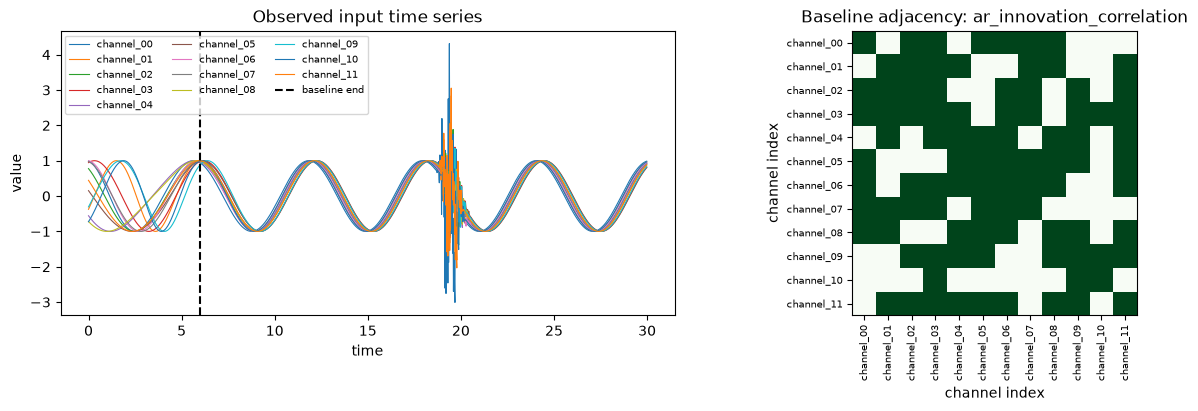

In [10]:
graph_result = build_graph(
    observed_values[:BASELINE_SIZE],
    GraphConfig(method="ar", edge_threshold=0.35, random_state=SEED),
)
adjacency = graph_result.adjacency.astype(bool)
edge_count = int(np.triu(adjacency, k=1).sum())
print(f"Graph method: {graph_result.method}; nodes: {len(channel_names)}; undirected edges: {edge_count}")
print("Channel order:", channel_names)

figure, axes = plt.subplots(1, 2, figsize=(13, 4), constrained_layout=True)
for node_index, channel_name in enumerate(channel_names):
    axes[0].plot(dataframe["timestamp"], observed_values[:, node_index], linewidth=0.8, label=channel_name)
axes[0].axvline(dataframe["timestamp"].iloc[BASELINE_SIZE], color="black", linestyle="--", label="baseline end")
axes[0].set(title="Observed input time series", xlabel="time", ylabel="value")
axes[0].legend(fontsize=7, ncol=3)
axes[1].imshow(adjacency, cmap="Greens", vmin=0, vmax=1)
axes[1].set(title=f"Baseline adjacency: {graph_result.method}", xlabel="channel index", ylabel="channel index")
axes[1].set_xticks(range(len(channel_names)), channel_names, rotation=90, fontsize=7)
axes[1].set_yticks(range(len(channel_names)), channel_names, fontsize=7)
plt.show()

## 2. Независимые размеченные эпизоды

Обучающий набор строится через `evt_demo.data_generator.generate_kuramoto_propagation_recording` — многособытийный аналог `generate_kuramoto_propagation_series` (той же функции, что породила реальный CSV выше), а не через упрощённый `make_recording` библиотеки (шум + синус). Каждая запись — это настоящая динамика связанных осцилляторов Курамото с несколькими независимо расположенными Hurst/DFA-окрашенными впрысками, распространяющимися по кольцу.

Это оказалось сложнее, чем звучит: `coupling` реального CSV (`0.7`) синхронизируется настолько медленно, что даже 900 отсчётов не всегда дают стационарный baseline для обучающих записей, поэтому здесь используется более быстрый `coupling=2.0` — иначе сам процесс синхронизации (не событие!) периодически пересекает EVT-порог. `baseline_size=900` — тоже не круглое число: при коротком baseline (300, как в исходной версии этого ноутбука) период колебаний Курамото (~300 отсчётов при этой скорости) регулярно давал ложные тревоги ещё до конца baseline. `EpisodeLabeler` находит события численно, сопоставляет их с ручными аннотациями и строит признаки узлов и baseline-граф; split ниже выполняется по целым записям.

In [11]:
TRAIN_COUPLING = 2.0     # faster-synchronizing than the real CSV's 0.7, so a finite baseline stays valid
TRAIN_BASELINE = 900     # must span several Kuramoto oscillation periods, not just "settled" coherence

labeling_pipeline = GraphEVTPipeline(
    EVTConfig(
        baseline_size=TRAIN_BASELINE,
        tail_quantile=0.90,
        alarm_probability=0.99,
        top_k=3,
        persistence=2,
    ),
    GraphConfig(method="ar", edge_threshold=0.35, random_state=SEED),
)
training_recordings = {}
training_annotations = {}
for recording_index in range(24):
    recording = generate_kuramoto_propagation_recording(
        n_events=4,
        n_channels=N_CHANNELS,
        seed=1_000 + recording_index,
        baseline_size=TRAIN_BASELINE,
        gap=150,
        coupling=TRAIN_COUPLING,
        hurst_exponent=propagation_metadata["hurst_exponent"],
        event_magnitude_in_sigma=propagation_metadata["event_magnitude_in_sigma"],
        delay_per_hop=propagation_metadata["delay_per_hop"],
        decay_per_hop=propagation_metadata["decay_per_hop"],
    )
    recording_id = f"training_recording_{recording_index:02d}"
    training_recordings[recording_id] = recording.as_input()
    training_annotations[recording_id] = list(zip(recording.event_times, recording.sources))

labels = EpisodeLabeler(
    labeling_pipeline,
    LabelingConfig(refractory=50, match_tolerance=25),
    verbose=True,
).label(training_recordings, annotations=training_annotations)
print("Episode labels:", labels.summary())
print("Skipped recordings:", labels.skipped)
pd.DataFrame(labels.to_records()).head()

Labelling episodes:   0%|          | 0/24 [00:00<?, ?it/s]

Episode labels: {'episodes': 113, 'manual': 72, 'pseudo': 4, 'abstained': 37, 'skipped_series': 0}
Skipped recordings: ()


,series_id,event_time,source,source_name,origin,confidence,margin,graph_method
0,training_recording_00,993,2.0,channel_02,manual,0.313898,0.132740,ar_innovation_correlation
1,training_recording_00,1157,NaN,NaN,abstained,0.295627,0.084023,ar_innovation_correlation
2,training_recording_00,1294,7.0,channel_07,manual,0.611914,0.508983,ar_innovation_correlation
3,training_recording_00,1449,11.0,channel_11,manual,0.542589,0.374464,ar_innovation_correlation
4,training_recording_00,1521,NaN,NaN,abstained,0.110826,0.010514,ar_innovation_correlation


Events in example recording: 5
   event_time      source label_origin  confidence
0         993  channel_02       manual    0.313898
1        1157         NaN    abstained    0.295627
2        1294  channel_07       manual    0.611914
3        1449  channel_11       manual    0.542589
4        1521         NaN    abstained    0.110826


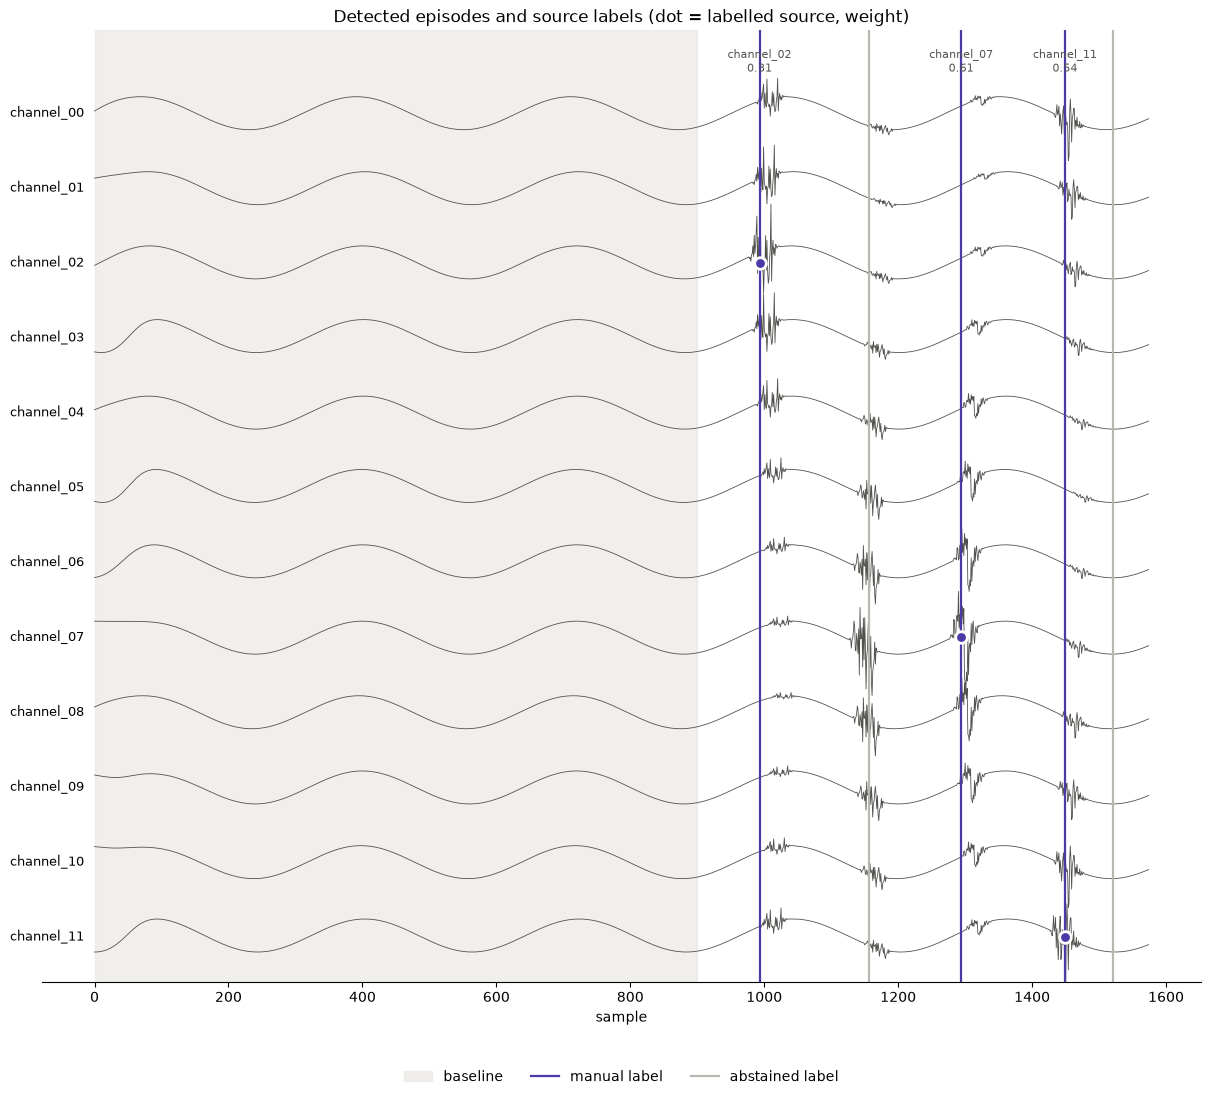

In [12]:
series_id = "training_recording_00"
training_input = training_recordings[series_id]
training_values = np.asarray(training_input.values, dtype=float)
series_labels = [item for item in labels.episodes if item.series_id == series_id]
print("Events in example recording:", len(series_labels))
print(pd.DataFrame([{
    "event_time": item.event_time,
    "source": item.source_name,
    "label_origin": item.origin,
    "confidence": item.confidence,
} for item in series_labels]))

viz.plot_labelled_recording(
    training_values,
    labels,
    series_id=series_id,
    channel_names=[f"channel_{index:02d}" for index in range(N_CHANNELS)],
    baseline_size=TRAIN_BASELINE,
)
plt.show()

## 3. Обучение с validation progress

`ProcessModelTrainer` обучает GNN/GAT, показывает прогресс по эпохам и сравнивает модели с прозрачной эвристикой. Validation выделяется целыми записями. Синтетические метрики иллюстрируют процедуру; они не обещают качества на реальных данных.

In [13]:
trainer = ProcessModelTrainer(
    GraphLearningConfig(hidden_dim=8, epochs=200, learning_rate=0.02, random_state=SEED),
    validation_fraction=0.25,
    k=3,
    random_state=SEED,
    verbose=True,
)
training_report = trainer.train(labels)
print("Training episodes:", training_report.n_train)
print("Validation episodes:", training_report.n_validation)
print("Validation split unit:", training_report.split_unit)
print("Best validation epoch:", training_report.best_epoch)
training_table = pd.DataFrame(training_report.summary_table())
training_table

Training GNN/GAT:   0%|          | 0/200 [00:00<?, ?it/s]

Training episodes: 59
Validation episodes: 17
Validation split unit: group
Best validation epoch: 63


,split,method,n,top1,top3,mrr,nll
0,train,heuristic,59,0.677966,0.881356,0.776722,1.292872
1,train,gnn,59,0.864407,0.932203,0.907647,0.381708
2,train,gat,59,0.898305,0.949153,0.930414,0.312768
3,validation,heuristic,17,0.647059,0.705882,0.725000,1.340636
4,validation,gnn,17,0.764706,0.764706,0.796104,0.920973
5,validation,gat,17,0.705882,0.764706,0.767766,1.492936


## 4. Три проверки: чужой домен, свой baseline не к месту, и правильный baseline

Одной "проверки на отложенных данных" недостаточно — ниже их три, и они показывают разные способы ошибиться:

1. **Другой домен, тот же baseline.** Отложенные эпизоды библиотеки (`make_propagation_episode`, шум + синус, `baseline_size=300`) — не из того распределения, на котором обучалась модель. Детекция пройдёт нормально (baseline короткий, но данные библиотеки стационарны), а вот GNN/GAT учились на признаках Kuramoto-записей и могут не перенестись на признаки другой генеративной модели.
2. **Свой домен, чужой baseline.** Реальный `kuramoto_propagation_series.csv` — из того же домена, что обучающие записи, но если наивно взять `baseline_size=900` (конвенция обучения) вместо этой конкретной записи, где `event_onset=932`, — событие почти сразу после конца baseline.
3. **Свой домен, свой baseline.** Тот же реальный ряд с `baseline_size=event_onset` — единственная из трёх проверок, где baseline действительно соответствует записи.

In [14]:
# Check 1: cross-domain -- library's own synthetic episodes (a different
# generative model), evaluated at their own well-tested baseline_size=300.
HELD_OUT_BASELINE = 300
labeled_test_episodes = [
    make_propagation_episode(
        n_channels=N_CHANNELS,
        source=episode_index % N_CHANNELS,
        baseline_size=HELD_OUT_BASELINE,
        length=600,
        topology="ring",
        gain_jitter=0.45,
        seed=8_000 + episode_index,
    )
    for episode_index in range(12)
]
labeled_cases = [
    EvaluationCase.from_synthetic(episode, case_id=f"heldout_synthetic_{index:02d}")
    for index, episode in enumerate(labeled_test_episodes)
]

heldout_pipeline = GraphEVTPipeline(
    EVTConfig(baseline_size=HELD_OUT_BASELINE, tail_quantile=0.90, alarm_probability=0.99, top_k=3, persistence=2),
    graph=GraphConfig(method="ar", edge_threshold=0.35, random_state=SEED),
    process_model=training_report.model,
    verbose=True,
)
heldout_evaluation = EvaluationOrchestrator(heldout_pipeline, early_tolerance=25, k=3, verbose=True).evaluate(labeled_cases)
print("Cross-domain summary:", heldout_evaluation.summary())
pd.DataFrame(heldout_evaluation.to_records())

Evaluating cases:   0%|          | 0/12 [00:00<?, ?it/s]

Cross-domain summary: {'n-d': {'cases': 12, 'hit': 12, 'miss': 0, 'early_alarm': 0, 'false_alarm': 0, 'correct_rejection': 0, 'unlabelled': 0, 'detection_rate': 1.0, 'false_alarm_rate': nan, 'mean_delay': 0.08333333333333333, 'median_delay': 0.0, 'heuristic_n': 12, 'heuristic_top1': 0.6666666666666666, 'heuristic_top3': 1.0, 'heuristic_mrr': 0.8333333333333334, 'gnn_n': 12, 'gnn_top1': 0.0, 'gnn_top3': 0.6666666666666666, 'gnn_mrr': 0.3333333333333333, 'gat_n': 12, 'gat_top1': 0.0, 'gat_top3': 0.0, 'gat_mrr': 0.10635521885521886}}


,case_id,route,outcome,stop_reason,detected_time,true_event_time,delay,true_source,heuristic_source,heuristic_rank,gnn_source,gnn_rank,gat_source,gat_rank
0,heldout_synthetic_00,n-d,hit,None,320,320,0,0,1,2,10,3,10,8
1,heldout_synthetic_01,n-d,hit,None,322,320,2,1,0,2,0,3,6,9
2,heldout_synthetic_02,n-d,hit,None,320,320,0,2,2,1,4,4,9,10
3,heldout_synthetic_03,n-d,hit,None,320,320,0,3,3,1,2,3,9,10
4,heldout_synthetic_04,n-d,hit,None,320,320,0,4,4,1,6,4,1,10
5,heldout_synthetic_05,n-d,hit,None,320,320,0,5,5,1,7,3,3,9
6,heldout_synthetic_06,n-d,hit,None,320,320,0,6,6,1,4,4,8,11
7,heldout_synthetic_07,n-d,hit,None,320,320,0,7,6,2,9,4,3,9
8,heldout_synthetic_08,n-d,hit,None,320,320,0,8,8,1,10,3,3,8
9,heldout_synthetic_09,n-d,hit,None,319,320,-1,9,9,1,7,3,0,9


Detection on the cross-domain episodes comes back clean (they're stationary by construction), which can look like success — but check the source columns above: `gnn_source`/`gat_source` wander away from `true_source` in a way `heuristic_source` mostly doesn't. A transparent heuristic degrades gracefully off-distribution; a learned scorer trained on Kuramoto-shaped node features does not automatically know what to do with library-synthetic ones.

### Check 2: same domain, but the training baseline convention

In [15]:
real_case_naive = EvaluationCase(
    real_input, event_time=real_event_onset, source=real_source_channel,
    case_id="Kuramoto propagation (real, naive baseline=TRAIN_BASELINE)",
)
naive_pipeline = GraphEVTPipeline(
    EVTConfig(baseline_size=TRAIN_BASELINE, tail_quantile=0.90, alarm_probability=0.99, top_k=3, persistence=2),
    graph=GraphConfig(method="ar", edge_threshold=0.35, random_state=SEED),
    process_model=training_report.model,
    verbose=True,
)
naive_evaluation = EvaluationOrchestrator(naive_pipeline, early_tolerance=25, k=3, verbose=True).evaluate([real_case_naive])
pd.DataFrame(naive_evaluation.to_records())

Evaluating cases:   0%|          | 0/1 [00:00<?, ?it/s]

,case_id,route,outcome,stop_reason,detected_time,true_event_time,delay,true_source,heuristic_source,heuristic_rank,gnn_source,gnn_rank,gat_source,gat_rank
0,"Kuramoto propagation (real, naive baseline=TRA...",n-d,hit,None,912,932,-20,0,5,10,7,11,6,3


`baseline_size=TRAIN_BASELINE` puts the alarm right at the edge of `early_tolerance`, close enough to still count as a `hit` -- timing looks fine. Source localization does not: `heuristic_source`/`gnn_source`/`gat_source` above land on the wrong channel across all three methods. `TRAIN_BASELINE=900` describes a *typical* recording in this generative family, not *this* one's actual pre-event window (`event_onset=932`) -- close in absolute terms, wrong in what matters, which is where the baseline graph and node features get computed. A `hit` on timing is not evidence the localization baseline was appropriate.

### Check 3: same domain, this recording's own baseline

Same fix every other `n-d` notebook already uses for this file: an oracle-assisted baseline ending at the real recording's own known `event_onset`.

In [16]:
real_pipeline = GraphEVTPipeline(
    EVTConfig(baseline_size=real_event_onset, tail_quantile=0.85, alarm_probability=0.97, top_k=3, persistence=1),
    graph=GraphConfig(method="ar", edge_threshold=0.35, random_state=SEED),
    process_model=training_report.model,
    verbose=True,
)
real_case = EvaluationCase(
    real_input, event_time=real_event_onset, source=real_source_channel,
    case_id="Kuramoto propagation (real, oracle baseline)",
)
real_evaluation = EvaluationOrchestrator(real_pipeline, early_tolerance=25, k=3, verbose=True).evaluate([real_case])
pd.DataFrame(real_evaluation.to_records())

Evaluating cases:   0%|          | 0/1 [00:00<?, ?it/s]

,case_id,route,outcome,stop_reason,detected_time,true_event_time,delay,true_source,heuristic_source,heuristic_rank,gnn_source,gnn_rank,gat_source,gat_rank
0,"Kuramoto propagation (real, oracle baseline)",n-d,hit,None,949,932,17,0,0,1,0,1,0,1


## Интерпретация

Тренировочные записи теперь строятся той же функцией (`generate_kuramoto_propagation_recording`), что и реальный CSV, а не упрощённым `make_recording` библиотеки — с реальной динамикой связанных осцилляторов и Hurst/DFA-окрашенными впрысками. Это честнее, но и труднее: доля `manual`-меток ниже, чем у прежней версии на простых синтетических данных, потому что слабый сигнал (`event_magnitude_in_sigma=2.0`, как в реальном ряде) местами неотличим от шума даже для самого детектора — а не только для модели.

Три проверки в разделе 4 расходятся по разным осям, и именно расхождение — содержательный результат:

- **Чужой домен (шум+синус библиотеки):** детекция в порядке, но GNN/GAT, обученные на Kuramoto-признаках, переносятся на признаки другой генеративной модели хуже прозрачной эвристики — она не выучена, поэтому ей нечего "не перенести".
- **Свой домен, чужой baseline:** обнаружение технически проходит (задержка укладывается в допуск), но локализация — нет, ни у эвристики, ни у GNN, ни у GAT. `hit` по времени не подтверждает, что baseline был уместен.
- **Свой домен, свой baseline:** и обнаружение, и локализация верны у всех трёх методов.

Ни одна из трёх проверок не заменяет другую — вместе они показывают, что "модель обучена" и "модель применена корректно к этому входу" разные утверждения. Малый synthetic benchmark — проверка исполнения на воспроизводимых данных, не оценка обобщения на реальные записи. Для реального исследования нужны независимые размеченные записи и untouched test set.

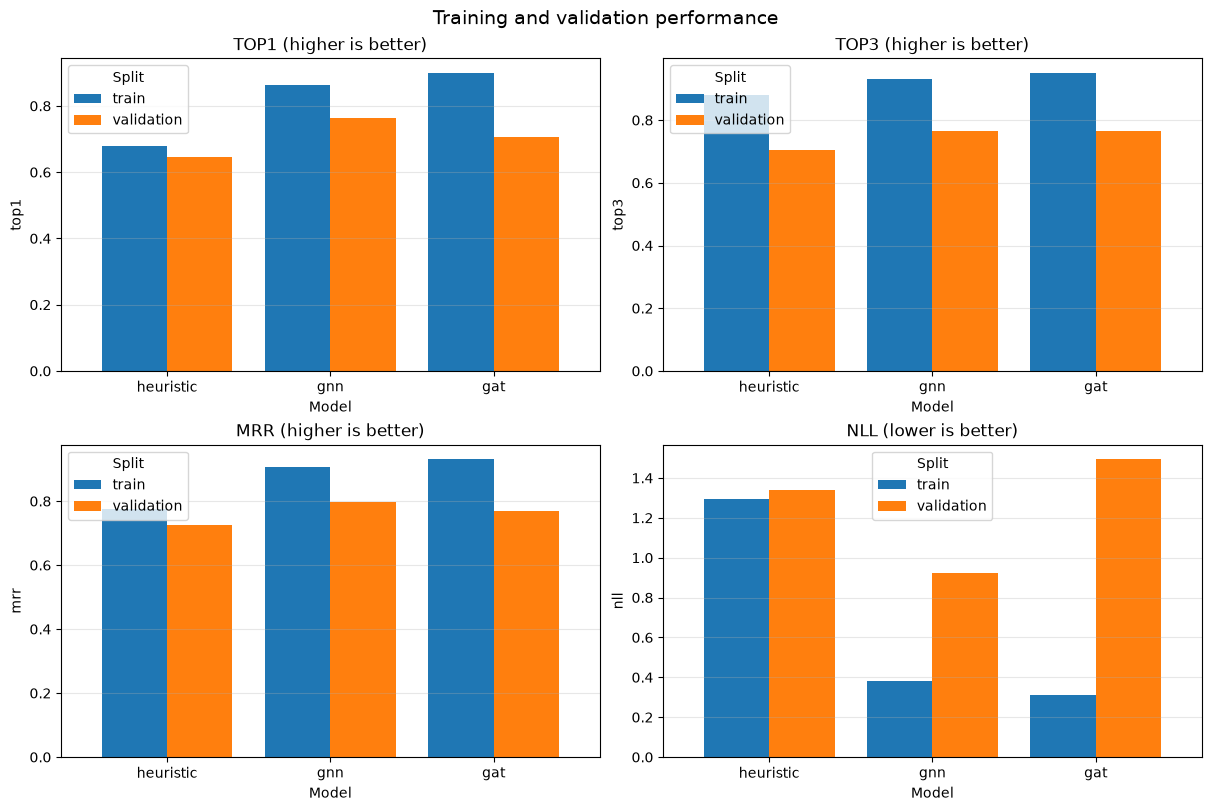

In [17]:
metrics = ["top1", "top3", "mrr", "nll"]
methods = training_table["method"].unique()
splits = training_table["split"].unique()

figure, axes = plt.subplots(2, 2, figsize=(12, 8), constrained_layout=True)
axes = axes.ravel()

for axis, metric in zip(axes, metrics):
    pivot = training_table.pivot(index="method", columns="split", values=metric)
    pivot = pivot.reindex(methods)

    pivot.plot(kind="bar", ax=axis, width=0.8)
    axis.set_title(metric.upper() + (" (lower is better)" if metric == "nll" else " (higher is better)"))
    axis.set_xlabel("Model")
    axis.set_ylabel(metric)
    axis.set_xticklabels(axis.get_xticklabels(), rotation=0)
    axis.grid(axis="y", alpha=0.3)
    axis.legend(title="Split")

plt.suptitle("Training and validation performance", fontsize=14)
plt.show()


[notice] A new release of pip is available: 25.1.1 -> 26.2.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


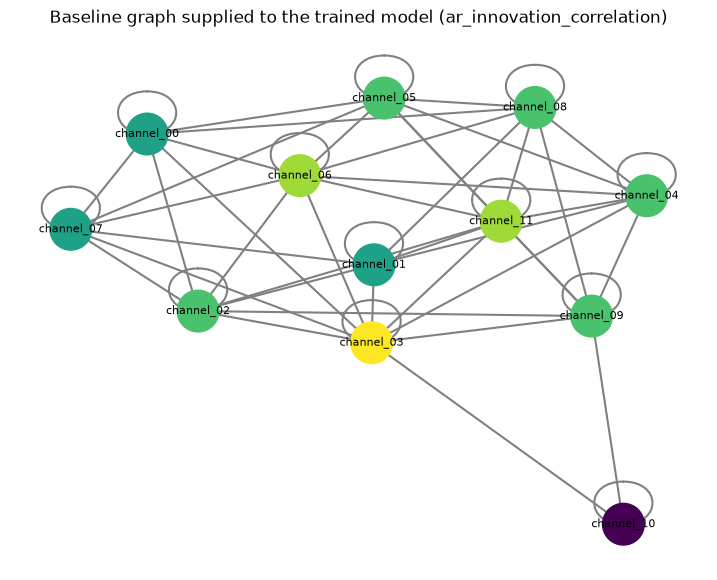

In [19]:
%pip install -q networkx

import networkx as nx

G = nx.from_numpy_array(graph_result.adjacency.astype(float))
nx.relabel_nodes(G, {i: name for i, name in enumerate(channel_names)}, copy=False)

degrees = dict(G.degree())
positions = nx.spring_layout(G, seed=SEED)

plt.figure(figsize=(9, 7))
nx.draw_networkx(
    G,
    pos=positions,
    labels={node: node for node in G.nodes},
    node_color=[degrees[node] for node in G.nodes],
    cmap="viridis",
    node_size=900,
    edge_color="gray",
    width=1.5,
    font_size=8,
)
plt.title(f"Baseline graph supplied to the trained model ({graph_result.method})")
plt.axis("off")
plt.show()